In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
df=pd.read_csv("diabetes.csv")

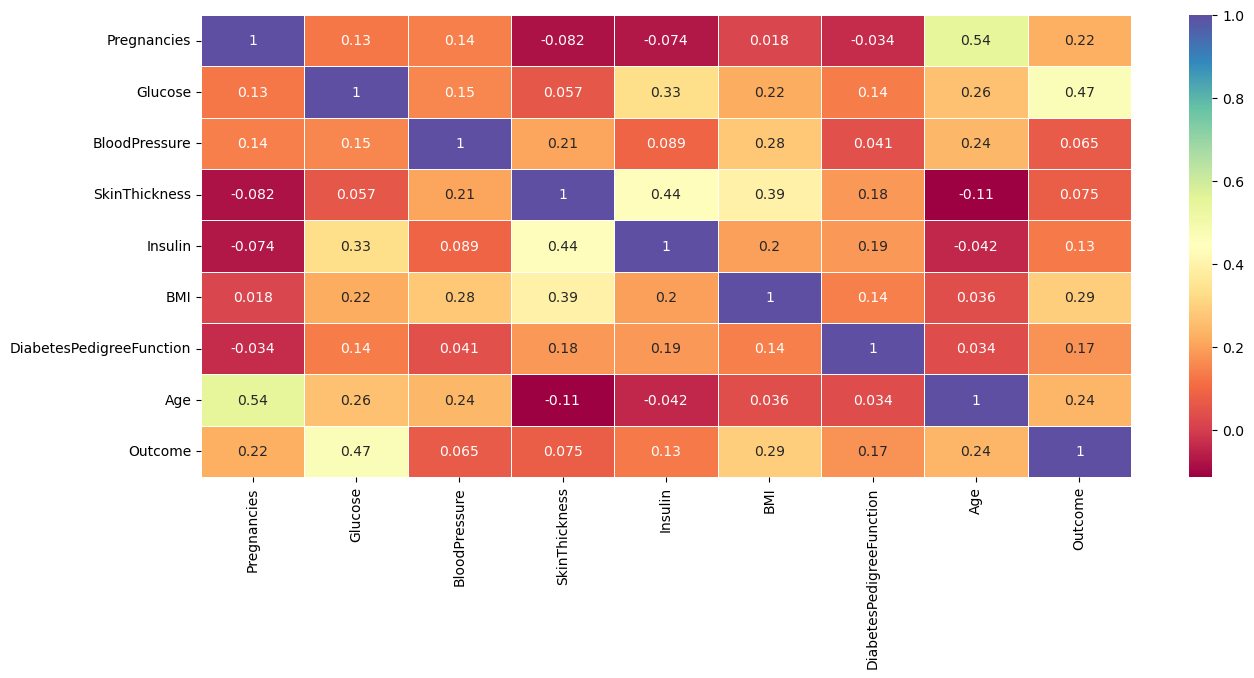

In [3]:
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(),annot=True,linewidth=0.5,cmap="Spectral")
plt.show()

In [4]:
# 1. Clean the Data: Replace impossible zeros with the column median
cols_to_fix = ["Glucose", "BloodPressure", "Insulin", "BMI"]
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

In [5]:
x = df.drop(["Outcome", "SkinThickness", "BloodPressure"], axis=1)
y = df["Outcome"]

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2, random_state=42)
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [8]:
y_pred=model.predict(x_test)

In [9]:
from sklearn.metrics  import classification_report
from sklearn.metrics  import confusion_matrix
print("logistic regression")
print(classification_report(y_test, y_pred))

logistic regression
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        99
           1       0.68      0.62      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier( n_estimators=100, 
    max_depth=5,        # Limits how complex the trees can get
    min_samples_leaf=5, # Ensures branches aren't based on single outliers
    random_state=42)
rf_model.fit(x_train, y_train)
y_rf_pred=rf_model.predict(x_test)

print("RandomForestClassifier")
print(classification_report(y_test, y_rf_pred))

RandomForestClassifier
              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



In [11]:

from sklearn.ensemble import GradientBoostingClassifier

X = df.drop(columns=["Outcome", "SkinThickness", "BloodPressure"])
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_final = gb_model.predict(X_test)
print("GradientBoostingClassifier")
print(classification_report(y_test, y_pred_final))


GradientBoostingClassifier
              precision    recall  f1-score   support

           0       0.82      0.77      0.79        99
           1       0.62      0.69      0.66        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154

